In [1]:
import numpy as np

from modelVelocity import ModelVelocity
from logProb import log_prob
from MCMC import MCMC
from readData import ReadData

import os
os.environ["OMP_NUM_THREADS"] = "1"

In [2]:
#Here we need to overload the ModelVelocity with the new host model. Hence, we also need to process the parameters differently.
class ModelVelocity_2S(ModelVelocity):

    def __init__(self, data):
        super().__init__(data)

    def set_params(self, x):

        self.Mbh = 10.**x[0]

        self.n = x[1::3]
        self.Mbulge = 10.**x[2::3]
        self.re_bulge = x[3::3]
    
        #Get the convenience constant Ie
        g_func_rnorm_max = self.g_func.rnorm_max
        self.Ie_bulge = np.zeros(len(self.Mbulge))
        for i, Mbulge in enumerate(self.Mbulge):
            self.Ie_bulge[i] = Mbulge/self.g_func.g_interp((self.n[i],g_func_rnorm_max))

        return

    def Mhost(self, r):
        Mh = 0
        g_func_rnorm_max = self.g_func.rnorm_max
        for i, Ie in enumerate(self.Ie_bulge):
            rnorm = r/self.re_bulge[i]
            #The following condition is needed because in one of the cases we will assume that the Re could be very small and the normalized radius could exceed 50Re for the outer rings. In those cases, we assume the mass is just converged. 
            rnorm = np.where(rnorm > g_func_rnorm_max, g_func_rnorm_max, rnorm)
            Mh += Ie * self.g_func.g_interp((self.n[i], rnorm))
        return Mh


## Initilizations

Here we first read the data file, using the [ReadData](readData.py) object. This is just for conveniency, but it is simply a function that reads and stores the relevant numbers in the file [data.dat](data.dat). 

The second step is to initialize the [ModelVelocity](modelVelocity.py) object, which holds a number of values relevant for the modeling and creates the interpolated values of the F and g functions. See the [README file](README.md) for more details. 

Finally, we set the boundaries for each of the parameters to be used during the MCMC. 

In [3]:
#Read the measurements. 
data = ReadData()

In [4]:
#Initialize the modeling object. This takes some time as some functions need to be interpolated. 
modelv = ModelVelocity_2S(data)

In [5]:
#Set the bounds for each of the parameters we will fit. 

#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min , n_host_max      = 0.50, 10.0 #Sersic index 
Re_host_min, Re_host_max     = 0.25, 10.0 #Effective radius in kpc. 
log_Mhost_min, log_Mhost_max = 8.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([log_Mbh_min, n_host_min,  log_Mhost_min, Re_host_min, n_host_min,  log_Mhost_min, Re_host_min])
params_max = np.array([log_Mbh_max, n_host_max,  log_Mhost_max, Re_host_max, n_host_max,  log_Mhost_max, Re_host_max])

## Case 1: Fit All Parameters

Here we allow all 6 paremeters to be fit to the data. 

In [6]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([0., 1.0, 10., 1.0, 4.0, 10.5, 2.0])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)
ifix[0] = True

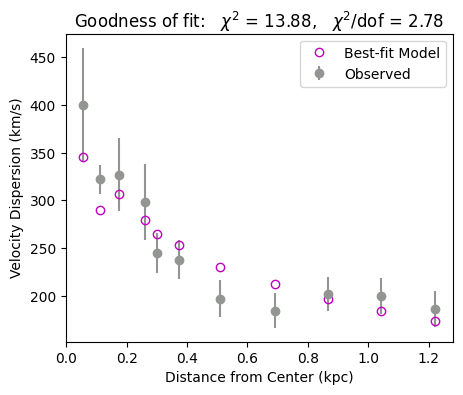

In [7]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
#myMCMC.runMCMC()

#Save the flatchain. 
#myMCMC.save_flat_samples("MCMC_flatchain.all_params.2S.txt")
myMCMC.load_flat_samples("MCMC_flatchain.all_params.2S.txt")

#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

#Make the corner plot.
#myMCMC.corner_plot()

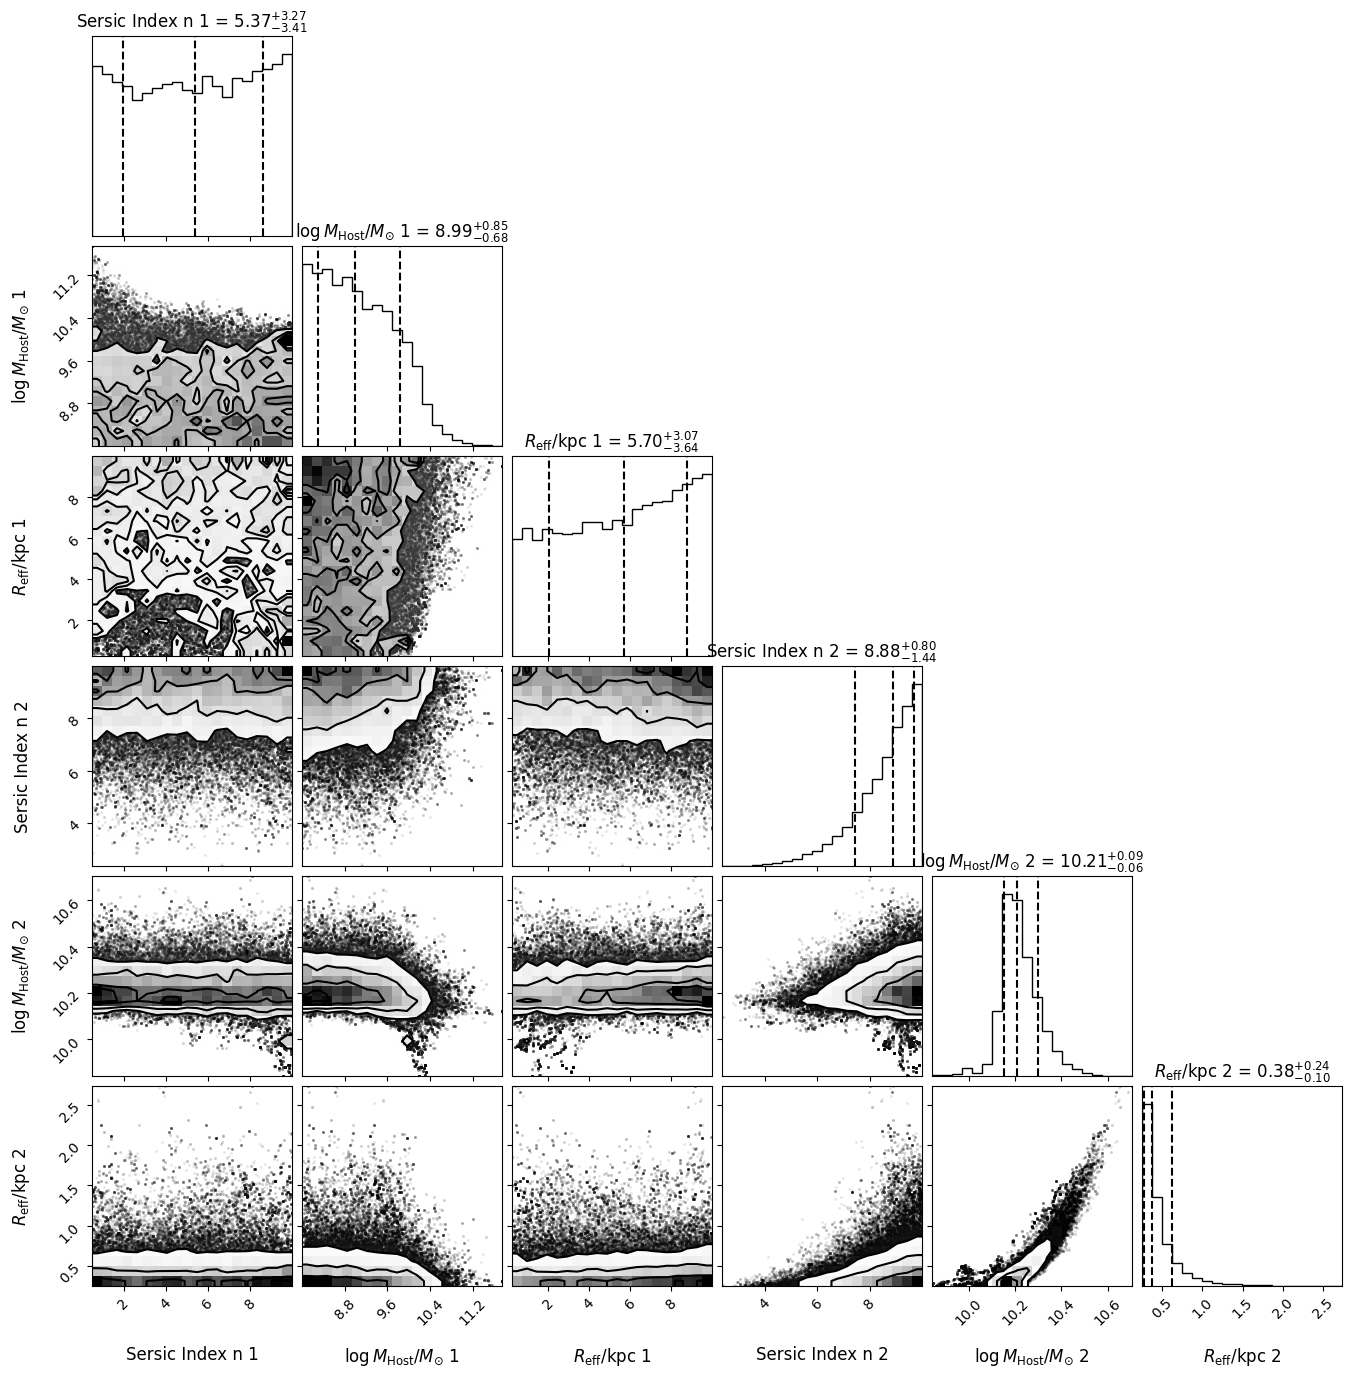

In [8]:
labels = [
    r"$\log M_{\rm BH}/M_{\odot}$",
    "Sersic Index n 1", 
    r"$\log M_{\rm Host}/M_{\odot}$ 1", 
    r"$R_{\rm eff}/{\rm kpc}$ 1",
    "Sersic Index n 2", 
    r"$\log M_{\rm Host}/M_{\odot}$ 2", 
    r"$R_{\rm eff}/{\rm kpc}$ 2",  
]

myMCMC.corner_plot(labels=labels)

## Case 2: Fit All Parameters with Constraints

Here we allow all 6 paremeters to be fit to the data. We use the constraints on the more extended component to be consistent with the JWST results. 

In [9]:
#SMBH Mass
log_Mbh_min  , log_Mbh_max   = 0.0 , 11.0 #Base 10 logarithm of the SMBH mass in units of Solar Masses.

#Host Galaxy Parameters
n_host_min1 , n_host_max1      = 0.50, 10.0 #Sersic index 
Re_host_min1, Re_host_max1     = 0.01,  0.5 #Effective radius in kpc. 
log_Mhost_min1, log_Mhost_max1 = 9.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

n_host_min2 , n_host_max2      = 0.50, 2.00 #Sersic index 
Re_host_min2, Re_host_max2     = 1.10, 1.60 #Effective radius in kpc. 
log_Mhost_min2, log_Mhost_max2 = 9.0 , 12.0 #Base 10 logarithm of the total host mass in units of Solar Masses.

#Put the bounds in the right format and order for the MCMC. 
params_min = np.array([log_Mbh_min, n_host_min1,  log_Mhost_min1, Re_host_min1, n_host_min2,  log_Mhost_min2, Re_host_min2])
params_max = np.array([log_Mbh_max, n_host_max1,  log_Mhost_max1, Re_host_max1, n_host_max2,  log_Mhost_max2, Re_host_max2])

In [10]:
#Initial guesses. Order is n, log Mbulge, re bulge, log Mbh.
params_init = np.array([0., 1.0, 10., 0.1, 1.5, 10.5, 1.25])
#params_init = np.array([0., 1.0, 10., 0.1, 4.0, 10.5, 2.0])

#Set which parameters are fixed. In this case, it is none, so it is just an array of False values.
ifix  = np.zeros(params_init.shape, dtype=bool)
ifix[0] = True

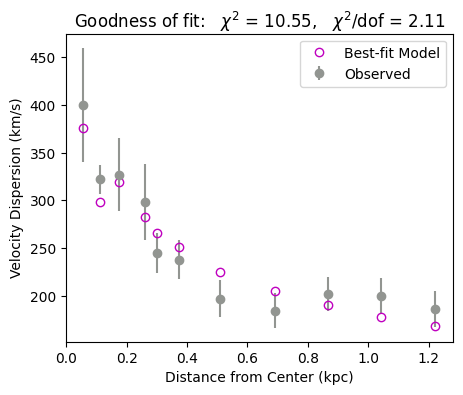

In [11]:
#####
# MCMC
#####

#Set the MCMC object, which is just a convenient wrapper for emcee. 
myMCMC = MCMC(params_init, params_min, params_max, modelv, log_prob, data.sigma_obs, data.sigma_obs_err, ifix=ifix)

#Run th MCMC
#myMCMC.runMCMC()

#Save the flatchain. 
#myMCMC.save_flat_samples("MCMC_flatchain.all_params.2S_constraints.txt")
myMCMC.load_flat_samples("MCMC_flatchain.all_params.2S_constraints.txt")

#Plot the best-fit model compared to the data. 
myMCMC.plot_bestfit()

#Make the corner plot.
#myMCMC.corner_plot()

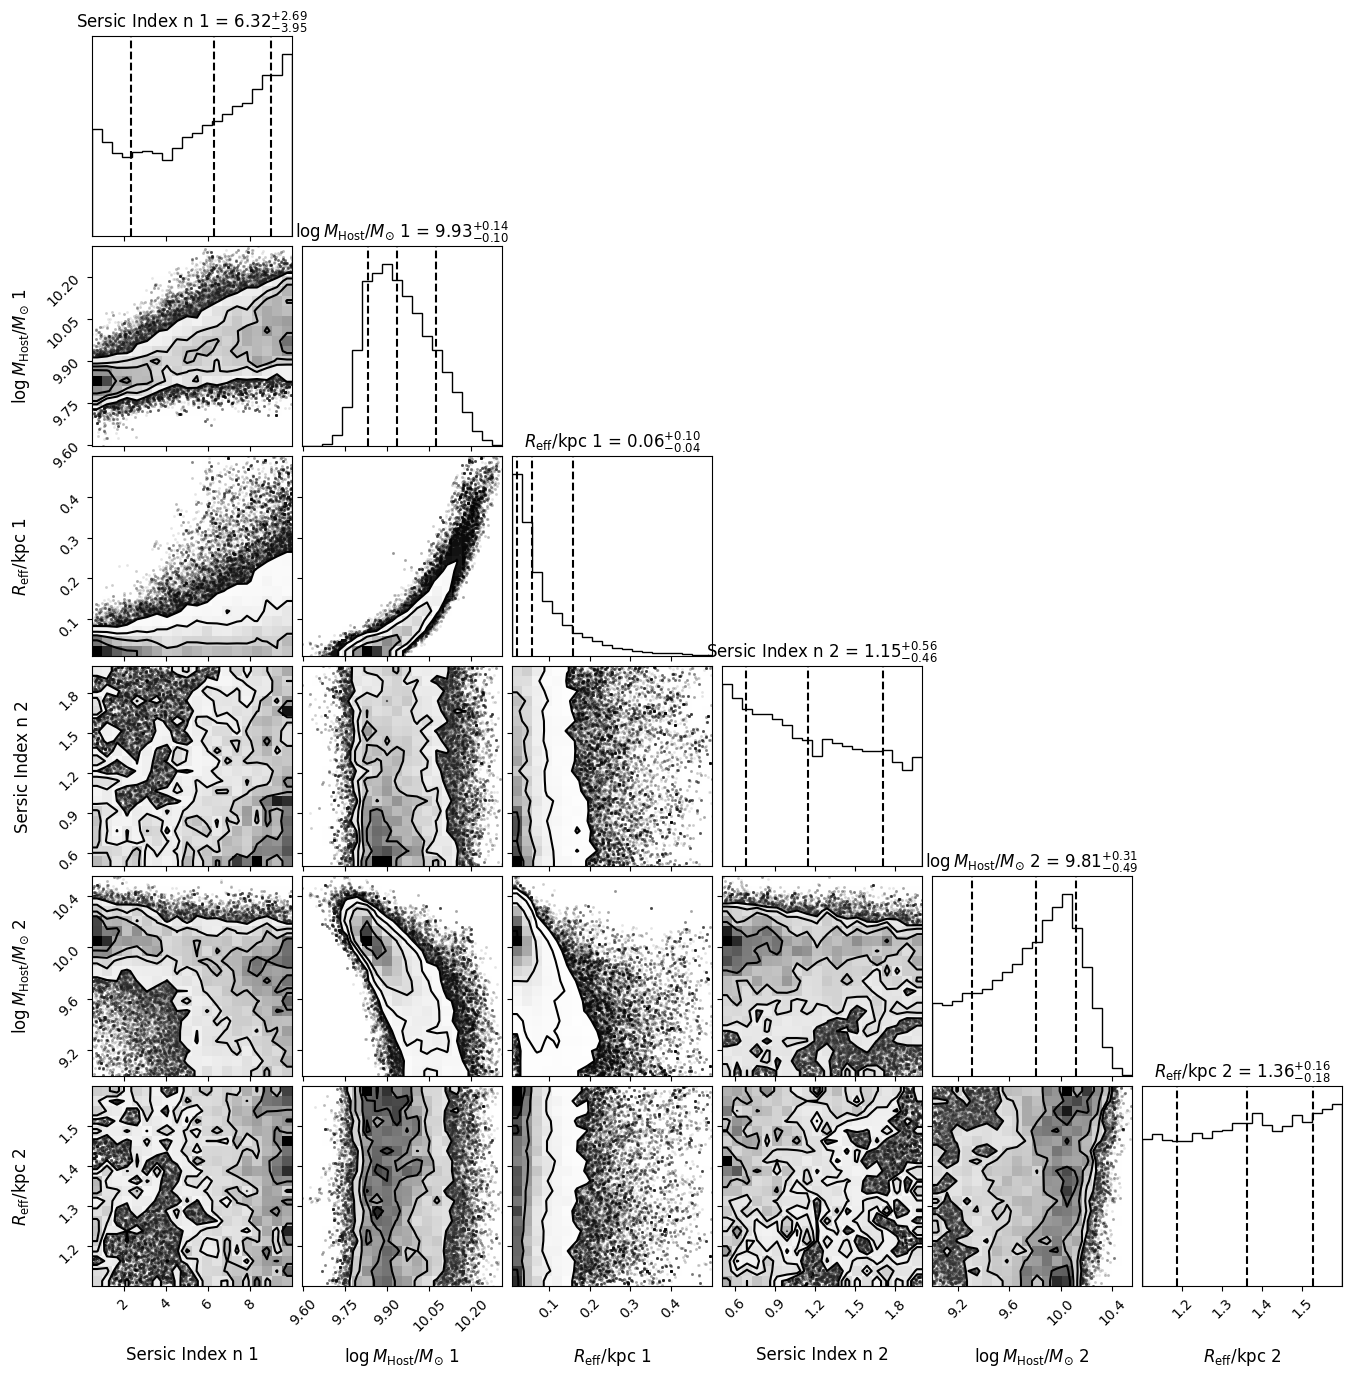

In [ ]:
labels = [
    r"$\log M_{\rm BH}/M_{\odot}$",
    "Sersic Index n", 
    r"$\log M_{\rm Host}/M_{\odot}$ 1", 
    r"$R_{\rm eff}/{\rm kpc}$ 1",
    "Sersic Index n 2", 
    r"$\log M_{\rm Host}/M_{\odot}$ 2", 
    r"$R_{\rm eff}/{\rm kpc}$ 2",  
]

myMCMC.corner_plot(labels=labels)